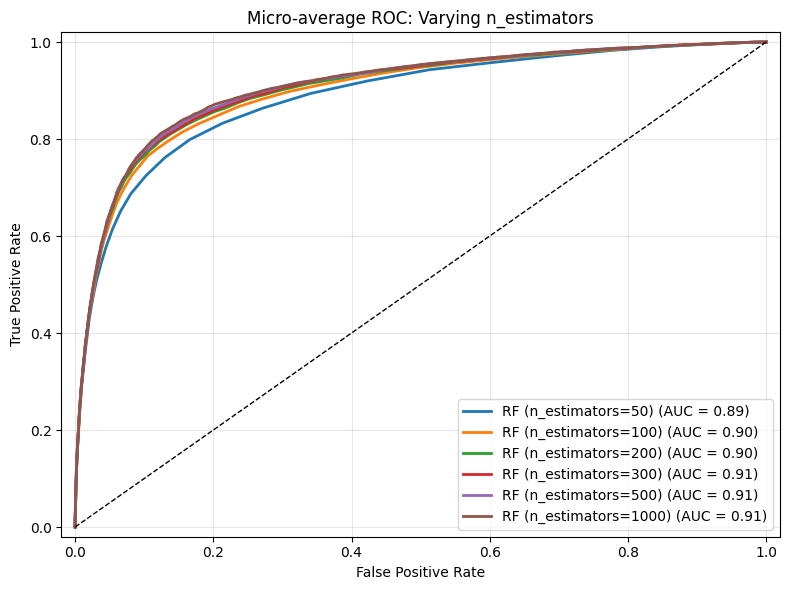

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# Binarize multiclass target
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)

# 2) Vary only n_estimators across 5 RF variants
n_list = [50, 100, 200, 300, 500, 1000]
rf_variants = {
    f'RF (n_estimators={n})': RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    for n in n_list
}

# 3) Fit each, compute micro-average ROC, and plot together
plt.figure(figsize=(8, 6))

for name, clf in rf_variants.items():
    ovr = OneVsRestClassifier(clf)
    ovr.fit(X_train, y_train)
    y_score = ovr.predict_proba(X_test)
    
    fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC: Varying n_estimators')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


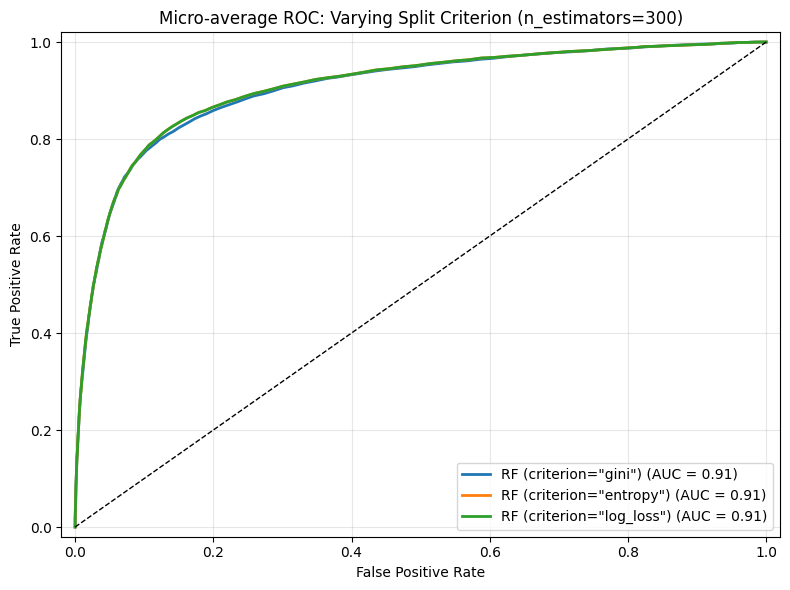

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# Binarize multiclass target
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)

# 2) Vary only the split criterion (fixed n_estimators=300)
criteria = ['gini', 'entropy', 'log_loss']
rf_variants = {
    f'RF (criterion="{c}")': RandomForestClassifier(
        n_estimators=300,
        criterion=c,
        random_state=42
    )
    for c in criteria
}

# 3) Fit each, compute micro-average ROC, and plot together
plt.figure(figsize=(8, 6))

for name, clf in rf_variants.items():
    ovr = OneVsRestClassifier(clf)
    ovr.fit(X_train, y_train)
    y_score = ovr.predict_proba(X_test)
    
    fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Diagonal reference
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC: Varying Split Criterion (n_estimators=300)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


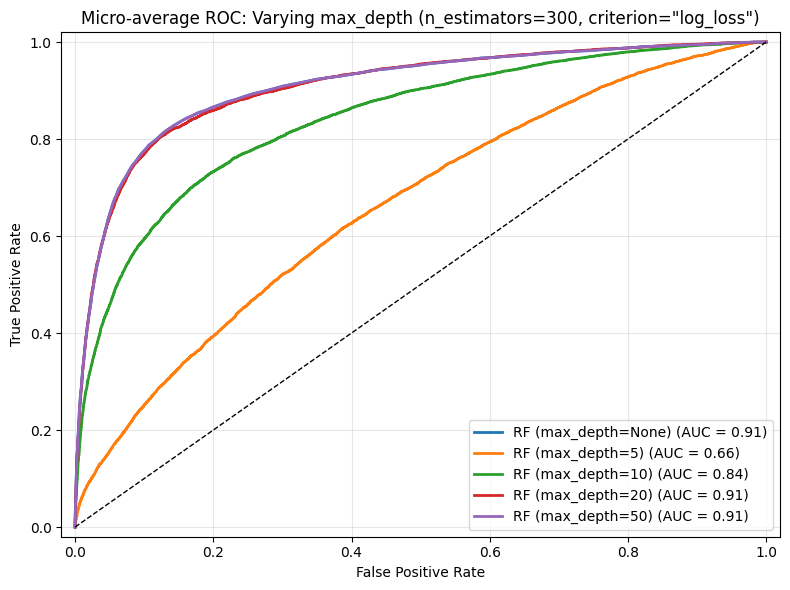

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# Binarize multiclass target
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)

# 2) Vary only max_depth (fixed n_estimators=300, criterion='log_loss')
depths = [None, 5, 10, 20, 50]
rf_variants = {
    f'RF (max_depth={d})': RandomForestClassifier(
        n_estimators=300,
        criterion='log_loss',
        max_depth=d,
        random_state=42
    )
    for d in depths
}

# 3) Fit each, compute micro-average ROC, and plot together
plt.figure(figsize=(8, 6))

for name, clf in rf_variants.items():
    ovr = OneVsRestClassifier(clf)
    ovr.fit(X_train, y_train)
    y_score = ovr.predict_proba(X_test)
    
    fpr, tpr, _ = roc_curve(y_test.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC: Varying max_depth (n_estimators=300, criterion="log_loss")')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


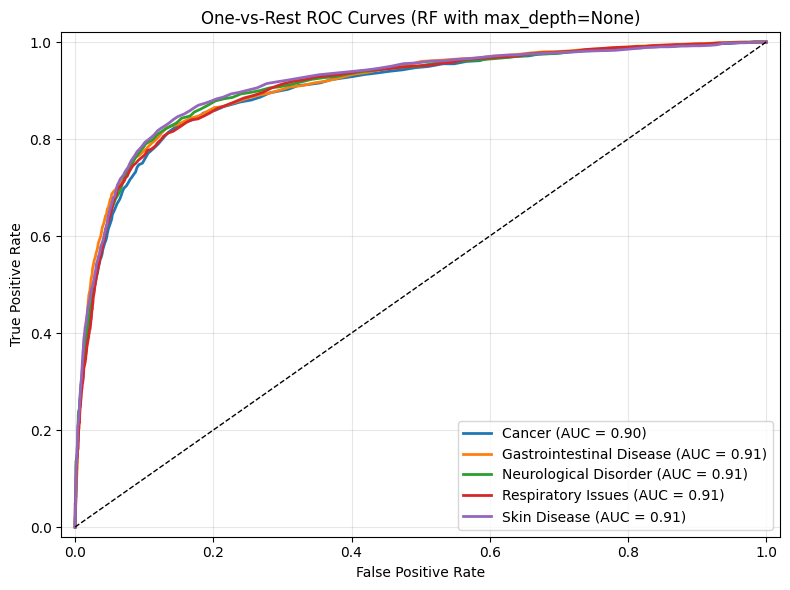

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# Binarize multiclass target
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)

# 2) Train RF with max_depth=None (and log_loss criterion, 300 trees)
rf = RandomForestClassifier(
    n_estimators=300,
    criterion='log_loss',
    max_depth=None,
    random_state=42
)
ovr = OneVsRestClassifier(rf)
ovr.fit(X_train, y_train)
y_score = ovr.predict_proba(X_test)

# 3) Plot one-vs-rest ROC curves for each class
plt.figure(figsize=(8,6))
for idx, class_name in enumerate(lb.classes_):
    fpr, tpr, _ = roc_curve(y_test[:, idx], y_score[:, idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

# Diagonal reference line
plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlim([-0.02,1.02])
plt.ylim([-0.02,1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves (RF with max_depth=None)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


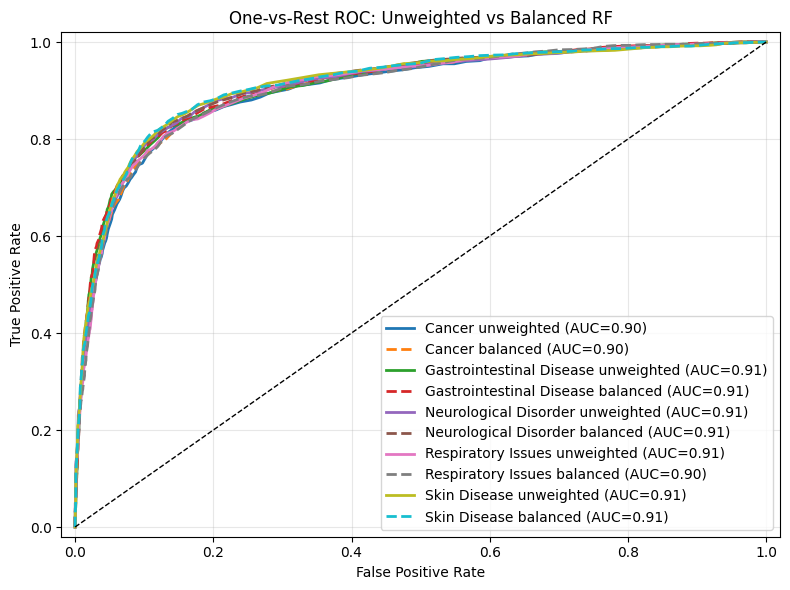

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')
X = pd.get_dummies(X, drop_first=True)

lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)

# 2) Two RF setups: unweighted vs. balanced
base_kwargs = dict(
    n_estimators=300,
    criterion='log_loss',
    max_depth=None,
    random_state=42
)

ovr_unweighted = OneVsRestClassifier(
    RandomForestClassifier(**base_kwargs)
)
ovr_balanced = OneVsRestClassifier(
    RandomForestClassifier(class_weight='balanced', **base_kwargs)
)

# Fit both
ovr_unweighted.fit(X_train, y_train)
ovr_balanced.fit(X_train, y_train)

y_score_unw = ovr_unweighted.predict_proba(X_test)
y_score_bal = ovr_balanced.predict_proba(X_test)

# 3) Plot per-class ROC curves for both
plt.figure(figsize=(8,6))
for idx, cls in enumerate(lb.classes_):
    fpr_u, tpr_u, _ = roc_curve(y_test[:,idx], y_score_unw[:,idx])
    fpr_b, tpr_b, _ = roc_curve(y_test[:,idx], y_score_bal[:,idx])
    plt.plot(fpr_u, tpr_u, lw=2, label=f'{cls} unweighted (AUC={auc(fpr_u,tpr_u):.2f})')
    plt.plot(fpr_b, tpr_b, lw=2, linestyle='--', label=f'{cls} balanced (AUC={auc(fpr_b,tpr_b):.2f})')

plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlim(-0.02,1.02); plt.ylim(-0.02,1.02)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC: Unweighted vs Balanced RF')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


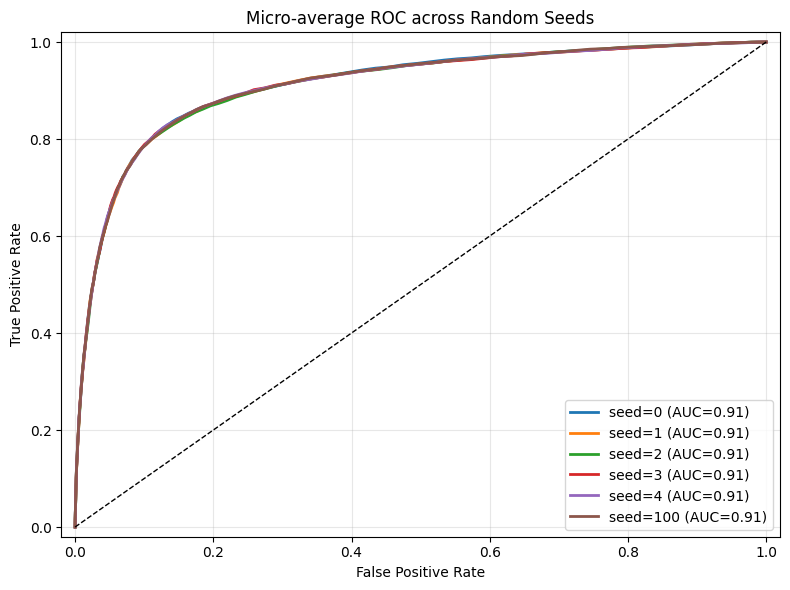

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')
X = pd.get_dummies(X, drop_first=True)

# Binarize target for ROC
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# Fixed train/test split
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)
y_train = lb.inverse_transform(y_train_bin)  # back to 1-d labels

# 2) Vary random seed, RF with balanced class weights
seeds = [0, 1, 2, 3, 4, 100]

plt.figure(figsize=(8, 6))
for seed in seeds:
    rf = RandomForestClassifier(
        n_estimators=300,
        criterion='log_loss',
        max_depth=None,
        class_weight='balanced',
        random_state=seed
    )
    rf.fit(X_train, y_train)
    y_score = rf.predict_proba(X_test)  # shape (n_samples, n_classes)

    # micro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'seed={seed} (AUC={roc_auc:.2f})')

# Diagonal reference
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC across Random Seeds')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


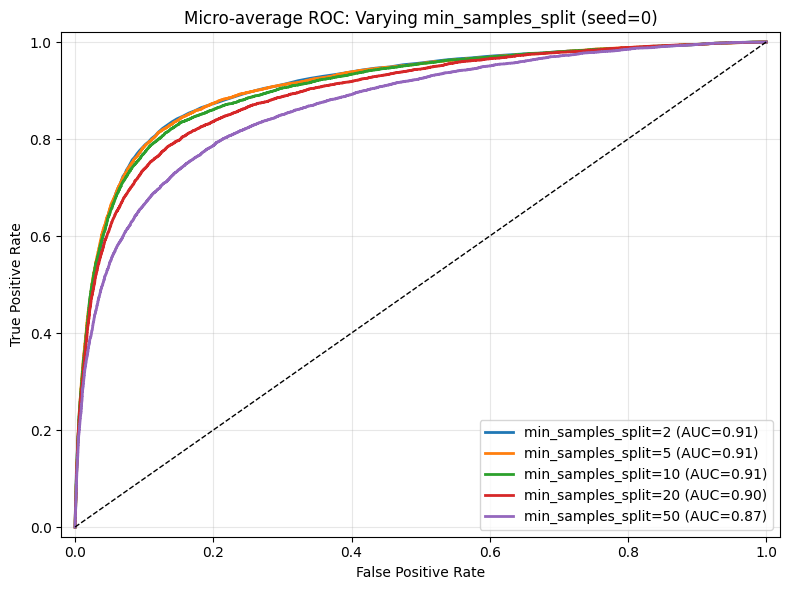

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')
X = pd.get_dummies(X, drop_first=True)

# 2) Binarize target for ROC
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# 3) Fixed train/test split
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)
y_train = lb.inverse_transform(y_train_bin)  # 1d labels for RF.fit

# 4) Vary min_samples_split with fixed seed=0
min_splits = [2, 5, 10, 20, 50]

plt.figure(figsize=(8, 6))
for m in min_splits:
    rf = RandomForestClassifier(
        n_estimators=300,
        criterion='log_loss',
        max_depth=None,
        class_weight='balanced',
        min_samples_split=m,
        random_state=0
    )
    rf.fit(X_train, y_train)
    y_score = rf.predict_proba(X_test)
    
    # micro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'min_samples_split={m} (AUC={roc_auc:.2f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC: Varying min_samples_split (seed=0)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


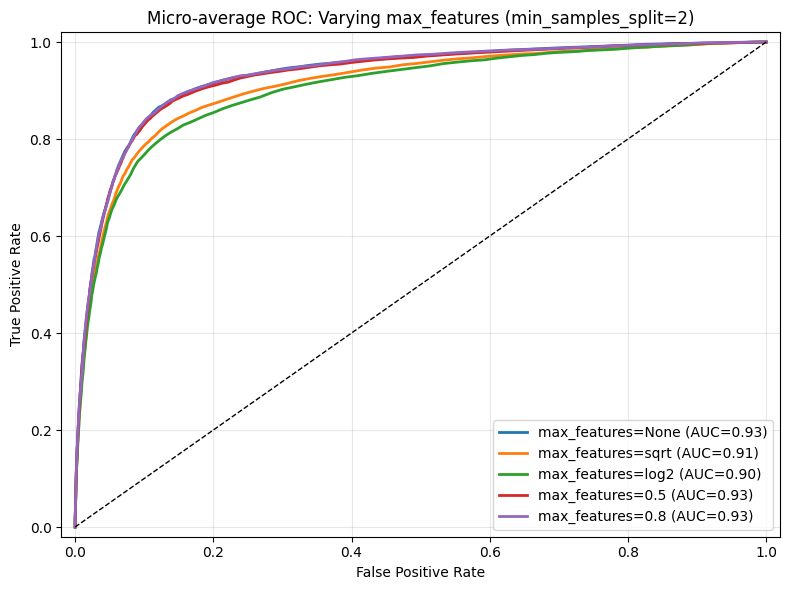

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')
X = pd.get_dummies(X, drop_first=True)

# 2) Binarize target for ROC
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# 3) Fixed train/test split
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)
y_train = lb.inverse_transform(y_train_bin)  # 1d labels for RF.fit

# 4) Vary max_features with fixed parameters
max_feats = [None, 'sqrt', 'log2', 0.5, 0.8]

plt.figure(figsize=(8, 6))
for mf in max_feats:
    rf = RandomForestClassifier(
        n_estimators=300,
        criterion='log_loss',
        max_depth=None,
        class_weight='balanced',
        min_samples_split=2,
        max_features=mf,
        random_state=0
    )
    rf.fit(X_train, y_train)
    y_score = rf.predict_proba(X_test)
    
    # micro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    label = f'max_features={mf}'
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC={roc_auc:.2f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC: Varying max_features (min_samples_split=2)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


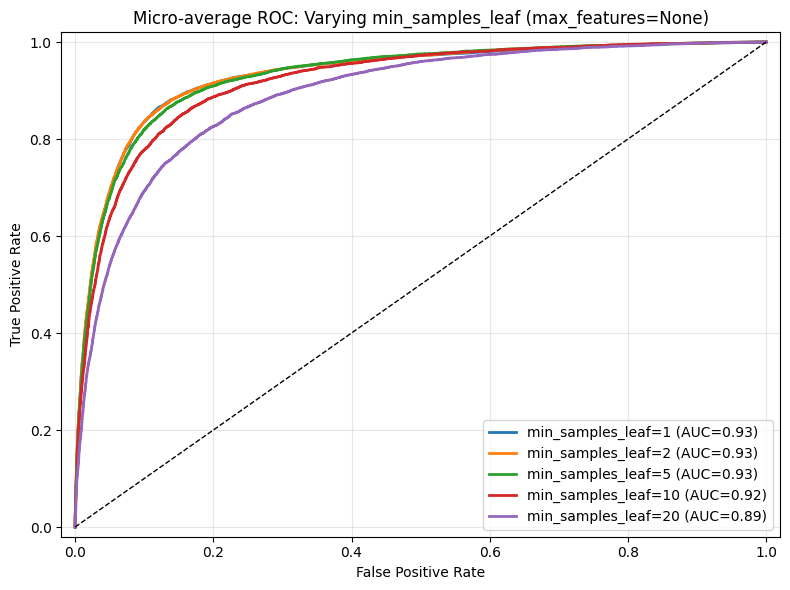

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')
y = df['Disease_Type']
X = pd.get_dummies(X, drop_first=True)

# 2) Binarize target for ROC
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)

# 3) Fixed train/test split
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.3, stratify=y, random_state=42
)
y_train = lb.inverse_transform(y_train_bin)  # 1d labels for RF.fit

# 4) Vary min_samples_leaf with max_features=None
leaf_options = [1, 2, 5, 10, 20]

plt.figure(figsize=(8, 6))
for leaf in leaf_options:
    rf = RandomForestClassifier(
        n_estimators=300,
        criterion='log_loss',
        max_depth=None,
        class_weight='balanced',
        min_samples_split=2,
        min_samples_leaf=leaf,
        max_features=None,
        random_state=0
    )
    rf.fit(X_train, y_train)
    y_score = rf.predict_proba(X_test)
    
    # micro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'min_samples_leaf={leaf} (AUC={roc_auc:.2f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Micro-average ROC: Varying min_samples_leaf (max_features=None)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ('scaler',    StandardScaler()),            # placeholder
    ('select',    SelectFromModel(               # placeholder
                     RandomForestClassifier(n_estimators=50, random_state=0),
                     threshold="mean"
                 )),
    ('pca',       PCA()),                        # placeholder
    ('clf',       RandomForestClassifier(class_weight='balanced', random_state=0))
])

param_grid = {
    # CHOOSING THE SCALER
    'scaler': [
        StandardScaler(),
        MinMaxScaler(),
        PowerTransformer(method='yeo-johnson')
    ],
    # FEATURE SELECTION THRESHOLD
    'select__threshold': ['median', 'mean', 0.01],
    # PCA COMPONENTS
    'pca__n_components': [None, 10, 20, 50],
    # RANDOM FOREST PARAMS
    'clf__n_estimators':    [100, 300],
    'clf__max_depth':       [None, 10, 25],
    'clf__min_samples_leaf':[1, 3, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid,
                  scoring='roc_auc_ovr',
                  cv=cv,
                  n_jobs=-1,
                  verbose=1)

gs.fit(X_train, y_train)
print("Best preprocessing + model combo:", gs.best_params_)


Fitting 5 folds for each of 648 candidates, totalling 3240 fits


c:\Users\Luca Agius\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1620 fits failed out of a total of 3240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
270 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Luca Agius\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Luca Agius\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c

Best preprocessing + model combo: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300, 'pca__n_components': None, 'scaler': MinMaxScaler(), 'select__threshold': 'mean'}


In [33]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# 1) parameter distributions
param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth':      [None] + list(range(5, 51, 5)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 20),
    'max_features':     ['sqrt', 'log2', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_rf = RandomForestClassifier(
    criterion='log_loss',
    class_weight='balanced',
    random_state=0
)

search = RandomizedSearchCV(
    base_rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc_ovr',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)
search.fit(X_train, y_train)
print("Best RF:", search.best_params_)
best_rf = search.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF: {'max_depth': 25, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 326}


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# 1) Load & preprocess
df = pd.read_csv('soil_csv_pre-processed.csv')
X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
y = df['Disease_Type']

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# 3) Fit RF with your ideal hyperparameters
params = {
    'n_estimators': 326,
    'max_depth': 25,
    'min_samples_split': 2,
    'min_samples_leaf': 3,
    'max_features': None,
    'class_weight': 'balanced',      # keep if you want balanced classes
    'criterion': 'log_loss',         # or 'gini' / 'entropy'
    'random_state': 0
}
rf = RandomForestClassifier(**params)
rf.fit(X_train, y_train)

# 4) Predictions & probabilities
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

# 5) KPIs

# 5a) Precision / Recall / F1
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# 5b) Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# 5c) Macro ROC-AUC
#    need to binarize y_test for multi-class AUC
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
roc_auc = roc_auc_score(y_test_bin, y_proba, 
                        average='macro', multi_class='ovr')
print(f"\nMacro ROC-AUC: {roc_auc:.3f}")


🔍 Evaluating model...

✅ Accuracy: 0.5726448474126493

📋 Classification Report:
                          precision    recall  f1-score   support

                  Cancer     0.3430    0.9141    0.4988      1850
Gastrointestinal Disease     0.8548    0.4798    0.6146      1730
   Neurological Disorder     0.8453    0.4716    0.6054      1796
      Respiratory Issues     0.8319    0.4859    0.6135      1741
            Skin Disease     0.8585    0.5008    0.6326      1927

                accuracy                         0.5726      9044
               macro avg     0.7467    0.5704    0.5930      9044
            weighted avg     0.7446    0.5726    0.5927      9044

🗺️ Confusion Matrix:
[[1691   30   38   61   30]
 [ 768  830   41   41   50]
 [ 837   35  847   36   41]
 [ 768   39   50  846   38]
 [ 866   37   26   33  965]]


ValueError: Found array with dim 3. None expected <= 2.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

# Load dataset
df = pd.read_csv('soil_csv_pre-processed.csv')
X = pd.get_dummies(df.drop(columns=['Disease_Type']), drop_first=True)
y = df['Disease_Type']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Prepare label encoder
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)


In [4]:
from sklearn.ensemble import RandomForestClassifier

# Define best parameters
params = {
    'n_estimators': 326,
    'max_depth': 25,
    'min_samples_split': 2,
    'min_samples_leaf': 3,
    'max_features': None,
    'class_weight': 'balanced',
    'criterion': 'log_loss',
    'random_state': 0
}

# Train the RF model
rf = RandomForestClassifier(**params)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', criterion='log_loss',
                       max_depth=25, max_features=None, min_samples_leaf=3,
                       n_estimators=326, random_state=0)

In [4]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression  # Simulating WNN with LR here

# Load dataset
df = pd.read_csv("soil_csv_pre-processed.csv")

# Separate features and labels
X = pd.get_dummies(df.drop(columns=["Disease_Type"]), drop_first=False)
y = df["Disease_Type"]

# Encode labels
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)
# You may still want y as categorical labels for multi-class classification
# In that case, use LabelEncoder instead:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train individual models
rf = KNeighborsClassifier(n_neighbors=5)
rf.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

wnn = LogisticRegression(max_iter=1000)
wnn.fit(X_train_scaled, y_train)

# Save models and transformers
joblib.dump(rf, "rf_soil_model.pkl")
joblib.dump(rf, "rf_soil_model.pkl")
joblib.dump(wnn, "wnn_soil_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(lb, "label_encoder.pkl")
joblib.dump(X.columns.tolist(), "X_encoded_columns.pkl")

print("✅ All models and encoders saved successfully.")


✅ All models and encoders saved successfully.


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Disease_Type'])
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']